In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import re
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adigo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
dataset = load_dataset("imdb")
df = pd.DataFrame(dataset['train'])

In [3]:
# Basic exploration
print(df.shape)
print(df['label'].value_counts())
df['review_length'] = df['text'].apply(lambda x: len(x.split()))#
print(df['review_length'].describe())

(25000, 2)
label
0    12500
1    12500
Name: count, dtype: int64
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64


In [8]:
# Match and replace strings in the reviews
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>","",text) #Remove html tags 
    text = re.sub(r"[^a-z\s]","",text) #remove everything that is not a lowercase letter or \s whitespace
    text = re.sub(r"\s+"," ",text).strip() #remove whitespace with leading and trailing edge
    return text

df['clean_text'] = df['text'].apply(clean_text)

[('the', 328128), ('and', 161576), ('a', 161314), ('of', 145166), ('to', 134822), ('is', 106802), ('in', 92187), ('it', 76313), ('this', 73186), ('i', 72477), ('that', 69199), ('was', 47988), ('as', 46059), ('with', 43724), ('for', 43701), ('movie', 41826), ('but', 40999), ('film', 37489), ('on', 33340), ('not', 30014)]


<function matplotlib.pyplot.show(close=None, block=None)>

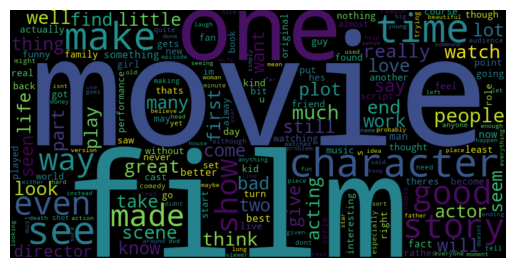

In [11]:
all_words = " ".join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)
print(common_words)

#Wordcloud plot
wordcloud = WordCloud(width = 800, height = 400).generate(" ".join(all_words))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show

In [ ]:
# Remove stop words like "the", "a", "me" etc.

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

df['filtered_text'] = df['clean_text'].apply(remove_stopwords)

In [ ]:
# Sentiment analysis with TextBlob

df['polarity']= df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
print(df.groupby('label')["polarity"].mean())

label
0    0.012184
1    0.190224
Name: polarity, dtype: float64
